In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import files

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.9.0+cu126
CUDA available: True


In [ ]:
filename = '/content/AMAZON_BEAUTY_27K_USERS.csv'

df = pd.read_csv(filename)
print("\n=== Preview Data ===")
print(df.head())
print(f"\nSố lượng: {len(df)} ratings")
print(f"Rating range: {df['Rating'].min()} - {df['Rating'].max()}")


=== Preview Data ===
                  UserId   ProductId          ProductType  Rating   Timestamp  \
0  A00414041RD0BXM6WK0GX  B00GRTQBTM  Trimmers & Clippers       5  1405296000   
1  A00414041RD0BXM6WK0GX  B00BQYYMN0   Kits & Accessories       3  1405296000   
2  A00414041RD0BXM6WK0GX  B008MIRO88          Conditioner       1  1405296000   
3  A00414041RD0BXM6WK0GX  B00870XLDS          Conditioner       2  1405296000   
4  A00414041RD0BXM6WK0GX  B007IY97U0          Body Lotion       3  1405296000   

                                                 URL    Brand  
0  https://www.amazon.in/Philips-BT3215-Cordless-...  PHILIPS  
1  https://www.amazon.in/SUGAR-POP-Exclusive-Esse...    SUGAR  
2  https://www.amazon.in/Garnier-Fructis-Strong-S...  GARNIER  
3  https://www.amazon.in/LOreal-Paris-RESIST-Cond...   LOREAL  
4  https://www.amazon.in/VENUSIA-Intensive-Moistu...  VENUSIA  

Số lượng: 235636 ratings
Rating range: 1 - 5


In [ ]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['UserId', 'ProductId', 'Rating']).reset_index(drop=True)
print("Total NaN in Rating after clean:", df['Rating'].isna().sum())

Total NaN in Rating after clean: 0


In [ ]:
users = list(df['UserId'].unique())
products = list(df['ProductId'].unique())

user2idx = {user: idx for idx, user in enumerate(users)}
product2idx = {product: idx for idx, product in enumerate(products)}

# Reverse mappings
idx2user = {idx: user for user, idx in user2idx.items()}
idx2product = {idx: product for product, idx in product2idx.items()}

num_users = len(users)
num_products = len(products)

print(f"users: {num_users}")
print(f"products: {num_products}")

# Convert tensor
user_indices = torch.tensor([user2idx[u] for u in df['UserId']], dtype=torch.long)
product_indices = torch.tensor([product2idx[p] for p in df['ProductId']], dtype=torch.long)
ratings = torch.tensor(df['Rating'].values, dtype=torch.float32)

print("NaN in ratings tensor:", torch.isnan(ratings).sum().item())
print(f"\nShape:")
print(f"- Users: {user_indices.shape}")
print(f"- Products: {product_indices.shape}")
print(f"- Ratings: {ratings.shape}")

users: 27485
products: 22129
NaN in ratings tensor: 0

Shape:
- Users: torch.Size([235636])
- Products: torch.Size([235636])
- Ratings: torch.Size([235636])


In [ ]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_users = user_indices[train_idx]
train_products = product_indices[train_idx]
train_ratings = ratings[train_idx]

val_users = user_indices[val_idx]
val_products = product_indices[val_idx]
val_ratings = ratings[val_idx]

test_users = user_indices[test_idx]
test_products = product_indices[test_idx]
test_ratings = ratings[test_idx]

print(f"\nTrain set: {len(train_idx)} samples ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_idx)} samples ({len(val_idx)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_idx)} samples ({len(test_idx)/len(df)*100:.1f}%)")

# Check rating distributions
print("\nTrain rating distribution:")
print(pd.Series(train_ratings.numpy()).value_counts().sort_index())

print("\nValidation rating distribution:")
print(pd.Series(val_ratings.numpy()).value_counts().sort_index())

print("\nTest rating distribution:")
print(pd.Series(test_ratings.numpy()).value_counts().sort_index())


Train set: 188508 samples (80.0%)
Validation set: 23564 samples (10.0%)
Test set: 23564 samples (10.0%)

Train rating distribution:
1.0     10718
2.0     11232
3.0     21030
4.0     36347
5.0    109181
Name: count, dtype: int64

Validation rating distribution:
1.0     1329
2.0     1405
3.0     2621
4.0     4593
5.0    13616
Name: count, dtype: int64

Test rating distribution:
1.0     1366
2.0     1362
3.0     2614
4.0     4560
5.0    13662
Name: count, dtype: int64


In [ ]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=16, hidden_dims=[64, 32], dropout=0.3):
        super(NCF, self).__init__()

        # Embedding layers
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.ln_user = nn.LayerNorm(embedding_dim)
        self.ln_item = nn.LayerNorm(embedding_dim)

        # Multi-layer perceptron (MLP)
        layers = []
        input_dim = embedding_dim * 2

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        # Output layer với Sigmoid (scale về [1, 5])
        layers.append(nn.Linear(input_dim, 1))
        layers.append(nn.Sigmoid())

        self.mlp = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user, item):
        # Get embeddings
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)

        user_emb = self.ln_user(user_emb)
        item_emb = self.ln_item(item_emb)

        # Concatenate embeddings
        x = torch.cat([user_emb, item_emb], dim=-1)

        # Pass through MLP
        output = self.mlp(x)
        output = output * 4.0 + 1.0

        return output.squeeze()

In [ ]:
EMBEDDING_DIM = 16
HIDDEN_DIMS = [64, 32]
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 256
EPOCHS = 100
DROPOUT = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = NCF(
    num_users,
    num_products,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("\n=== TRAINING CONFIGURATION ===")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"Hidden dimensions: {HIDDEN_DIMS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Dropout: {DROPOUT}")
print(f"Epochs: {EPOCHS}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")


=== TRAINING CONFIGURATION ===
Embedding dimension: 16
Hidden dimensions: [64, 32]
Learning rate: 0.001
Weight decay: 0.0001
Batch size: 256
Dropout: 0.4
Epochs: 100
Model parameters: 798,305
Device: cuda


In [ ]:
def train_epoch(model, users, products, ratings, criterion, optimizer, batch_size, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    # Shuffle index mỗi epoch
    indices = torch.randperm(len(users))

    for i in range(0, len(users), batch_size):
        batch_idx = indices[i:i+batch_size]
        batch_users = users[batch_idx].to(device)
        batch_products = products[batch_idx].to(device)
        batch_ratings = ratings[batch_idx].to(device)

        optimizer.zero_grad()
        predictions = model(batch_users, batch_products)
        loss = criterion(predictions, batch_ratings)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


In [ ]:
def evaluate(model, users, products, ratings, criterion, batch_size, device):
    model.eval()
    predictions_list = []

    with torch.no_grad():
        for i in range(0, len(users), batch_size):
            batch_users = users[i:i+batch_size].to(device)
            batch_products = products[i:i+batch_size].to(device)

            batch_preds = model(batch_users, batch_products)
            predictions_list.append(batch_preds.cpu())

    predictions = torch.cat(predictions_list)

    ratings_cpu = ratings.cpu()

    # Metrics
    mse = criterion(predictions, ratings_cpu).item()
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(ratings_cpu.numpy(), predictions.numpy())

    return mse, rmse, mae, predictions


In [ ]:
train_losses = []
train_rmses = []
val_rmses = []
learning_rates = []

best_val_rmse = float('inf')
patience_counter = 0
PATIENCE = 8

print("\n" + "=" * 70)
print("STARTING TRAINING WITH TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_epoch(
        model, train_users, train_products, train_ratings,
        criterion, optimizer, BATCH_SIZE, device
    )

    # Evaluate
    train_mse, train_rmse, train_mae, _ = evaluate(
        model, train_users, train_products, train_ratings,
        criterion, BATCH_SIZE, device
    )
    val_mse, val_rmse, val_mae, _ = evaluate(
        model, val_users, val_products, val_ratings,
        criterion, BATCH_SIZE, device
    )

    train_losses.append(train_loss)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)


    scheduler.step(val_rmse)

    # Early stopping
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        patience_counter = 0
        torch.save(model.state_dict(), 'best_ncf_model_fixed.pth')
        print(f"Saved best model at epoch {epoch+1} (Val RMSE improved: {val_rmse:.4f})")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Train RMSE: {train_rmse:.4f}, Train MAE: {train_mae:.4f}")
        print(f"  Val RMSE:   {val_rmse:.4f}, Val MAE:   {val_mae:.4f}")
        print(f"  Gap (Val - Train): {(val_rmse - train_rmse):.4f}")
        print(f"  Learning Rate: {current_lr:.6f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break


STARTING TRAINING WITH TRAIN / VALIDATION / TEST SPLIT
Saved best model at epoch 1 (Val RMSE improved: 1.1372)

Epoch 1/100
  Train Loss: 1.4710
  Train RMSE: 1.0570, Train MAE: 0.8242
  Val RMSE:   1.1372, Val MAE:   0.8944
  Gap (Val - Train): 0.0801
  Learning Rate: 0.001000
Saved best model at epoch 2 (Val RMSE improved: 1.1260)

Epoch 5/100
  Train Loss: 0.7900
  Train RMSE: 0.7671, Train MAE: 0.5310
  Val RMSE:   1.2021, Val MAE:   0.8561
  Gap (Val - Train): 0.4350
  Learning Rate: 0.001000

Epoch 10/100
  Train Loss: 0.4293
  Train RMSE: 0.5474, Train MAE: 0.3415
  Val RMSE:   1.2781, Val MAE:   0.8619
  Gap (Val - Train): 0.7306
  Learning Rate: 0.000500

Early stopping at epoch 10


In [ ]:
# Load best model
model.load_state_dict(torch.load('best_ncf_model_fixed.pth', map_location=device))

test_mse, test_rmse, test_mae, test_preds = evaluate(
    model, test_users, test_products, test_ratings,
    criterion, BATCH_SIZE, device
)

print("\n=== Final Evaluation on Test Set ===")
print(f"Test MSE : {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE : {test_mae:.4f}")
print(f"Prediction range on test: [{test_preds.min():.2f}, {test_preds.max():.2f}]")
print(f"Unique rounded predictions: {len(torch.unique(test_preds.round()))}/5")


=== Final Evaluation on Test Set ===
Test MSE : 1.2759
Test RMSE: 1.1295
Test MAE : 0.8646
Prediction range on test: [2.80, 4.80]
Unique rounded predictions: 3/5


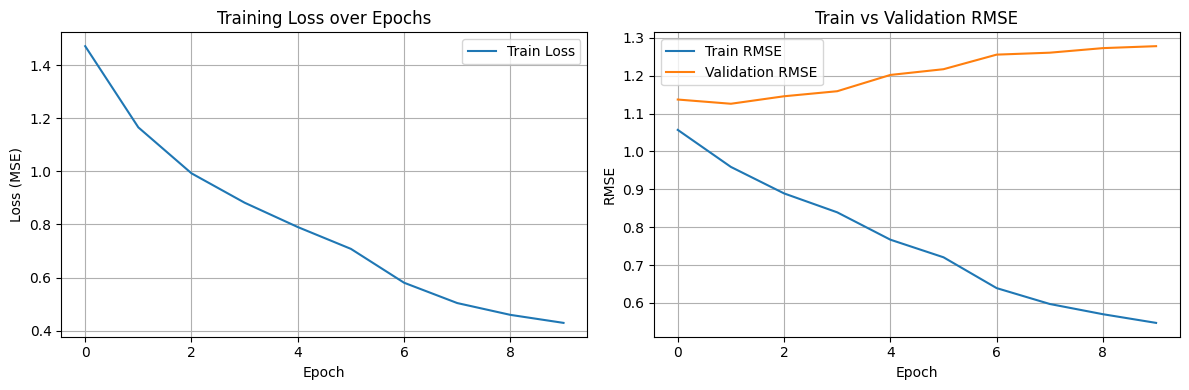

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_rmses, label='Train RMSE')
plt.plot(val_rmses, label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Train vs Validation RMSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()